# Train smaller or finetune larger models

In [1]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.example_autoencoder as eae
import lpips
import matplotlib.pyplot as plt
import math, random
import os
import time
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
from datetime import datetime
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from datetime import timedelta

dataset='fantasy'
batch_size=2
target_size=256

cp_path = 'checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth'
if cp_path:
    cfgdict = ch.check_checkpoint(cp_path)['config']
    cfg = eae.HBQAutoencoderConfig(**cfgdict)
    print(cfg)
else:
    cfg = eae.HBQAutoencoderConfig(
        in_channels=3, 
        base_dim=96, 
        channel_multipliers=(1, 2, 3, 4, 5), 
        res_blocks=(1, 1, 2, 2, 3), 
        latent_dim=32, quant_dim=8, n_rounds=4
    )



🔄 Loading checkpoint from checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4, 5), 'res_blocks': (1, 1, 2, 2, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}
HBQAutoencoderConfig(in_channels=3, base_dim=96, channel_multipliers=(1, 2, 3, 4, 5), res_blocks=(1, 1, 2, 2, 3), latent_dim=32, quant_dim=8, n_rounds=4)


In [2]:
if resume_from_legacy_checkpoint_format := False:
    path = 'checkpoints/legacy_finetune_256_5_bd_96_ld_32_qd_8.pth'
    old_cp = torch.load(path,map_location='cpu')
    autoencoder = eae.load_legacy_quant_checkpoint(autoencoder, old_cp['model_state_dict'])
    autoencoder.eval()

if cp_path:
    autoencoder = eae.ExampleQuantizingAutoencoder(cfg)
    ch.load_checkpoint(autoencoder,None,cp_path)
pass
#autoencoder.to('cuda')
#with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
#    autoencoder(torch.rand(5,3,256,256,device="cuda"))[0].shape

🔄 Loading checkpoint from checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4, 5), 'res_blocks': (1, 1, 2, 2, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}


In [3]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
        self.files = []
        for ext in exts:
            self.files.extend(Path(root).rglob(ext))
        self.files = sorted(self.files)
        print(f"Found {len(self.files)} images.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize(target_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = ImageDataset(
    root=f"./data/256x256/{dataset}",
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

print(f"{len(train_dataset)} training images")
next(iter(train_loader)).shape

Found 12814 images.
12814 training images


torch.Size([2, 3, 256, 256])

In [4]:

import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np
import hierarchical_binary_quantization.misc.image_helpers as ih
import IPython.display as ipd

def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(ih.q_out_to_rgb(aux.quant_info.quantized)[0])
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
    h = ih.html_for_images([original, latent, reconstruction],min_height=256)
    return h, original, latent, reconstruction

# imgs = next(iter(train_loader)).to('cpu')
# h,*i2 = show_reconstructions(autoencoder, imgs)
# ipd.display(ipd.HTML(h))


In [5]:
quantizer = hbq.QuantizerRandomizer([
    hbq.HBQQuantizer(n_rounds=1),
    hbq.HBQQuantizer(n_rounds=2),
    hbq.HBQQuantizer(n_rounds=3),
    hbq.HBQQuantizer(n_rounds=4),
    hbq.HBQQuantizer(n_rounds=3),
    hbq.HBQQuantizer(n_rounds=4),
    hbq.HBQQuantizer(n_rounds=3),
    hbq.HBQQuantizer(n_rounds=4),
])

autoencoder.quantizer = quantizer

# quant_dim=8, n_rounds = 4 = 32 bits
training_device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

autoencoder.to(training_device)
optimizer = torch.optim.AdamW(
    autoencoder.parameters(),
    lr=1e-4, # 3e-4 often fails to converge on Cats&Dogs dataset (mostly brown; local minima of all brown images can be found with huge weights)
    weight_decay=1e-4,
)

if cp_path:
    ch.load_checkpoint(autoencoder, optimizer, cp_path, strict=True)

print(autoencoder.config)
print(
    f"Parameters: {sum(p.numel() for p in autoencoder.parameters())/1e6:.2f}M"
)


🔄 Loading checkpoint from checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4, 5), 'res_blocks': (1, 1, 2, 2, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}
HBQAutoencoderConfig(in_channels=3, base_dim=96, channel_multipliers=(1, 2, 3, 4, 5), res_blocks=(1, 1, 2, 2, 3), latent_dim=32, quant_dim=8, n_rounds=4)
Parameters: 54.32M


## Train The Model

In [6]:
import torch.nn.functional as F
def color_difference_loss(pred, target):
    return (
        F.l1_loss(pred[:,0]-pred[:,1], target[:,0]-target[:,1]) +
        F.l1_loss(pred[:,0]-pred[:,2], target[:,0]-target[:,2]) +
        F.l1_loss(pred[:,1]-pred[:,2], target[:,1]-target[:,2])
    )


In [7]:

quantizer = hbq.QuantizerRandomizer([
        hbq.HBQQuantizer(n_rounds=1),
        hbq.HBQQuantizer(n_rounds=2),
        hbq.HBQQuantizer(n_rounds=3),
        hbq.HBQQuantizer(n_rounds=4),
        hbq.HBQQuantizer(n_rounds=3),
        hbq.HBQQuantizer(n_rounds=4),
        hbq.HBQQuantizer(n_rounds=3),
        hbq.HBQQuantizer(n_rounds=4),
])
autoencoder.quantizer = quantizer


In [8]:

import torch
import time
from tqdm import tqdm
import torch.nn.functional as F

def train_some(autoencoder, optimizer, train_loader, device, 
               continued_training_elapsed_time=0,
               continued_training_item_counter=0,
               epochs=1,grad_checkpointing=False,
               max_training_time = 60 * 60 * 24 * 7
              ):
    autoencoder.to(device)
    autoencoder.set_grad_checkpointing(grad_checkpointing)

    loss_history = []
    t0 = time.time()
    item_counter = 0
    display_interval = 1
    next_display = t0 + display_interval
    loss_fn = lpips.LPIPS(net='vgg').eval().requires_grad_(False).to(device)    
    
    scaler = torch.amp.GradScaler('cuda')
    
    for epoch in range(epochs):
        autoencoder.train()
        running_loss = 0.0
        progress = tqdm(train_loader)
        for imgs in progress:
            if time.time() - t0 > max_training_time:
                break
            imgs = imgs.to(device)
            optimizer.zero_grad()
            batch_size = imgs.shape[0]
            item_counter += batch_size
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                recon, aux = autoencoder(imgs)
                loss_lpips = loss_fn(recon, imgs).sum()
                loss_l1 = F.l1_loss(recon, imgs)
                loss_color = color_difference_loss(recon, imgs)
                loss = (loss_l1 + 2.0 * loss_lpips + 0.5 * loss_color)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
            running_loss += loss.item()
            progress.set_description(f"Epoch {epoch+1}/{epochs} {loss.item():.3f}")
            
            if time.time() > next_display:
                total_training_time = time.time() - t0 + continued_training_elapsed_time
                next_display = time.time() + display_interval
                display_interval = min(1.2*display_interval, 60*30)

                print(
                    f"time={str(timedelta(seconds=total_training_time))} "
                    f"items = {continued_training_item_counter + item_counter} "
                    f"Loss={loss.item():.3f} "
                    f"l1={loss_l1.item():.3f} lpips{loss_lpips.item():.3f} clr{loss_color.item():.3f} "
                    f"latent μ={aux.latents.mean().item():.3f} "
                    f"σ={aux.latents.std().item():.3f}"
                )
                h, *imgs_show = show_reconstructions(autoencoder, imgs)
                #debug_latent_correlations(aux.latents)
                ipd.display(ipd.HTML(h))
    
        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1:2d}: {epoch_loss:.6f}")

In [9]:
train_some(autoencoder, optimizer, train_loader,device=training_device,max_training_time=60,epochs=0)
autoencoder.eval()
pass

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth


In [10]:
def debug_latent_correlations(latent):
    with torch.no_grad():
        z = latent  # (B,C,H,W), BEFORE tanh
        # One row per channel, one column per sample/pixel
        x = z.permute(1, 0, 2, 3).reshape(z.shape[1], -1)
        # Center each channel
        x = x - x.mean(dim=1, keepdim=True)
        # Normalize each channel to unit variance
        x = x / (x.std(dim=1, keepdim=True) + 1e-8)
        # Correlation matrix
        corr = (x @ x.T) / x.shape[1]
        print("Channel correlation:")
        print(corr.cpu().numpy().round(2))
        offdiag = corr - torch.eye(corr.shape[0], device=corr.device)
        mean_abs_corr = offdiag.abs().sum() / (corr.numel() - corr.shape[0])
        print(f"Mean |off-diagonal correlation| = {mean_abs_corr:.3f}")
with torch.no_grad():
    i,aux = autoencoder(next(iter(train_loader)).to(training_device))
# A suggestion from ChatGPT to debug if color was bottlenecked before the quantizer.
print(aux.latents.shape, aux.quant_info.quantized.shape, aux.quant_info.tokens.shape)
debug_latent_correlations(autoencoder.pre_quant(aux.latents))

torch.Size([2, 32, 16, 16]) torch.Size([2, 8, 16, 16]) torch.Size([2, 16, 16])
Channel correlation:
[[ 1.    0.03 -0.04  0.15  0.15  0.01 -0.13  0.02]
 [ 0.03  1.   -0.23  0.2   0.02  0.73  0.01  0.29]
 [-0.04 -0.23  1.   -0.33  0.08 -0.3   0.22 -0.17]
 [ 0.15  0.2  -0.33  1.    0.04  0.2  -0.02  0.11]
 [ 0.15  0.02  0.08  0.04  1.    0.02  0.11 -0.05]
 [ 0.01  0.73 -0.3   0.2   0.02  1.   -0.37  0.72]
 [-0.13  0.01  0.22 -0.02  0.11 -0.37  1.   -0.37]
 [ 0.02  0.29 -0.17  0.11 -0.05  0.72 -0.37  1.  ]]
Mean |off-diagonal correlation| = 0.184


In [ ]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
cls_name = autoencoder.__class__.__name__

unet_steps = len(autoencoder.config.channel_multipliers)
tag = f"finetune_{target_size}_{unet_steps}_bd_{autoencoder.config.base_dim}_ld_{autoencoder.config.latent_dim}_qd_{autoencoder.config.quant_dim:}"
path = f"checkpoints/{cls_name}_{timestamp}_{tag}.pth"
    
save_checkpoint(path,autoencoder,optimizer)

In [12]:
histogram = torch.bincount(aux.quant_info.tokens[0].flatten())
histogram

tensor([ 0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  2,  0,  2,  0,  0,  0,  2,  0,  0,  0,  3,
         1,  0,  0,  2,  0,  0, 13,  2,  0,  0,  1,  0,  1,  0,  7,  3,  1,  0,
         4,  0,  1,  1,  1,  4,  0,  0,  1,  1,  3,  1,  2,  0, 18,  1,  0,  1,
         3,  1,  0,  1,  2,  0,  0,  0,  6,  1,  0,  0, 12,  4,  0,  3,  6,  1,
         0,  1,  4,  0,  0,  0,  0,  0,  1,  3,  0,  0,  5,  2,  0,  0, 12, 15,
         0,  0,  7, 17,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0, 19,  0,  0,
         4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  1,  0,  0,  0,  1,  0,  0,  0,  3,  2,  0,  0,  2,  1,  1,  2,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0, 

In [14]:
!ls -l checkpoints checkpoints/good

checkpoints:
total 1910732
-rw-rw-r-- 1 ron ron 652186821 Aug  3 19:19 ExampleQuantizingAutoencoder_2026-08-03_19-19-49_finetune_256_5_bd_96_ld_32_qd_8.pth
-rw-rw-r-- 1 ron ron 652186821 Aug  3 19:46 ExampleQuantizingAutoencoder_2026-08-03_19-46-21_finetune_256_5_bd_96_ld_32_qd_8.pth
-rw-rw-r-- 1 ron ron 652186821 Aug  3 19:51 ExampleQuantizingAutoencoder_2026-08-03_19-51-17_finetune_256_5_bd_96_ld_32_qd_8.pth
drwxrwxr-x 2 ron ron      4096 Aug  3 20:32 good
drwxrwxr-x 2 ron ron      4096 Aug  3 18:14 old_model

checkpoints/good:
total 1910732
-rw-rw-r-- 1 ron ron 652186821 Aug  3 19:52 2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth
-rw-rw-r-- 1 ron ron 652186821 Aug  3 18:08 f_256_bd_96_ld_32_qd_8_new.pth
-rw-rw-r-- 1 ron ron 652196699 Aug  3 13:47 f_256_bd_96_ld_32_qd_8.pth


In [21]:
cp_path = 'checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth'
cfg = ch.check_checkpoint(cp_path)['config']

🔄 Loading checkpoint from checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4, 5), 'res_blocks': (1, 1, 2, 2, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}


In [23]:
autoencoder_cpu = ExampleQuantizingAutoencoder(**cfg)
load_checkpoint(autoencoder_cpu,optimizer,cp_path)
pass

🔄 Loading checkpoint from checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4, 5), 'res_blocks': (1, 1, 2, 2, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}


Warning - this project defaults to +/- 1 for most tensors
unique tokens=250 out of 4294967296.



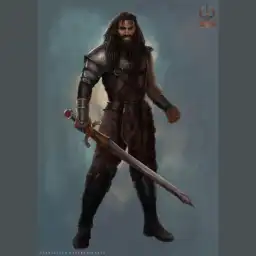
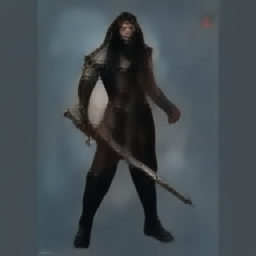

In [33]:
imgs = next(iter(train_loader))
h,*i2 = show_reconstructions(autoencoder_cpu, imgs.to('cpu'))
ipd.HTML(h)


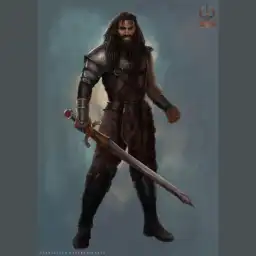
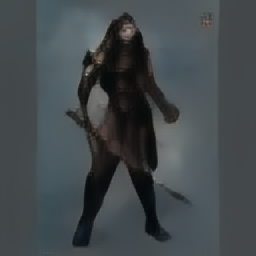
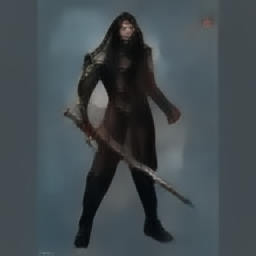
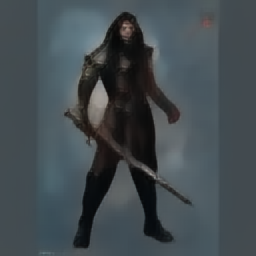
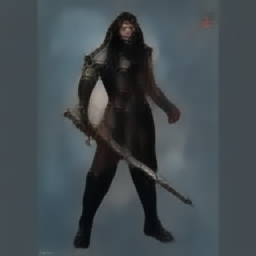
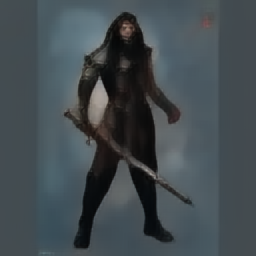

In [34]:
from hierarchical_binary_quantization.hbq import (
    bit_codes_to_tokens, tokens_to_bit_codes, bit_codes_to_quantized_latent,
)
@torch.inference_mode()
def decode_all_levels(autoencoder, imgs, max_rounds=4):
    """bit_codes: (B, L, H, W) int, full-resolution accumulated codes.
    Returns {round: images (B, C, H, W) in [0,1]} for round in 1..max_rounds."""
    with torch.inference_mode():
        reconstructions, aux = autoencoder(imgs[:1])

    latents = aux.latents
    bit_codes = aux.quant_info.bit_codes
    original = imgs[0].detach().cpu().permute(1,2,0)
    results = {}
    results['orig'] = original
    for r in range(1, max_rounds + 1):
        r_bits = bit_codes >> (max_rounds - r)                    # (B, L, H, W)
        r_bits = r_bits.permute(0, 2, 3, 1)                        # (B, H, W, L)
        quantized = bit_codes_to_quantized_latent(r_bits, n_rounds=r)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()     # (B, L, H, W)
        z = autoencoder.post_quant(quantized)
        images = autoencoder.backbone.decode(z)
        #images = (images / 2 + 0.5).clamp(0, 1)
        results[r] = images.cpu()
    if True:
        inf = autoencoder.backbone.decode(autoencoder.post_quant(autoencoder.pre_quant(latents)))
        #inf = (inf / 2 + 0.5).clamp(0, 1)
        results['inf'] = inf.cpu()
    return results
levels = decode_all_levels(autoencoder_cpu,imgs)
all_imgs = [levels['orig'], levels[1][0], levels[2][0], levels[3][0], levels[4][0], levels['inf'][0]]
titles = ["original","round1", "round2", "round3", "round4", "round infinity"]
zimgs = [ih.tensor_to_pil(i) for i in all_imgs]
ipd.display(ipd.HTML(ih.html_for_images(zimgs, title=" / ".join(titles), min_height=128)))